In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arnavkulkarni/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:

df = pd.read_csv('data_science.csv')

# Display first 5 rows
print(df.head())

                    id      conversation_id               created_at  \
0  1406400408545804288  1406400396264943616  2021-06-20 05:26:01 IST   
1  1406390341176016897  1406390341176016897  2021-06-20 04:46:01 IST   
2  1406386311481774083  1406386311481774083  2021-06-20 04:30:00 IST   
3  1406383545153638402  1406383545153638402  2021-06-20 04:19:01 IST   
4  1406358632648818689  1406358632648818689  2021-06-20 02:40:01 IST   

         date      time  timezone              user_id         username  \
0  2021-06-20  05:26:01       530  1113747629282930688  ballouxfrancois   
1  2021-06-20  04:46:01       530   788898706586275840     tdatascience   
2  2021-06-20  04:30:00       530             19402238      sciencenews   
3  2021-06-20  04:19:01       530   788898706586275840     tdatascience   
4  2021-06-20  02:40:01       530   788898706586275840     tdatascience   

                    name place  ... geo source user_rt_id user_rt retweet_id  \
0  Prof Francois Balloux   NaN  ... 

/var/folders/vb/1znqf43s76z47sg4_zysyyj80000gn/T/ipykernel_82820/3692459948.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data_science.csv')


In [6]:
print(df.columns)


Index(['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone',
       'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions',
       'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count',
       'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video',
       'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest'],
      dtype='object')


In [8]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [12]:
analyzer = SentimentIntensityAnalyzer()

In [14]:
def get_sentiment(tweet):

    score = analyzer.polarity_scores(str(tweet))

    compound = score['compound']

    if compound >= 0:
        return 'Positive'
    else:
        return 'Negative'

In [16]:
df['Sentiment'] = df['tweet'].apply(get_sentiment)

In [18]:
print(df[['tweet', 'Sentiment']].head())

                                               tweet Sentiment
0  What can be done?  - Never blindly trust an ab...  Negative
1  "We need a paradigm shift from model-centric t...  Positive
2  Using high-resolution satellite data and compu...  Positive
3  .@Stephenson_Data shares four steps that will ...  Positive
4  "Curricula is inherently brittle in a world wh...  Positive


In [20]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    217403
Negative     23983
Name: count, dtype: int64


In [22]:
df.to_csv('classified_tweets.csv', index=False)

In [24]:
positive_tweets = df[df['Sentiment'] == 'Positive']

print(positive_tweets[['tweet', 'Sentiment']].head(10))

                                                tweet Sentiment
1   "We need a paradigm shift from model-centric t...  Positive
2   Using high-resolution satellite data and compu...  Positive
3   .@Stephenson_Data shares four steps that will ...  Positive
4   "Curricula is inherently brittle in a world wh...  Positive
6   @LinkLabsInc @IoTchannel Wow! Wonderful!! Cong...  Positive
7   Register now and build your #HPEDiscover 2021 ...  Positive
8   What is #ModelOps vs. #MLOps? “ModelOps is key...  Positive
9   Demystifying #AI with 10 top applications:  ht...  Positive
10  Trends in #AI for next 5 years, including reve...  Positive
11  “1001 Free Things” You Can Do with Your Data —...  Positive


In [26]:
negative_tweets = df[df['Sentiment'] == 'Negative']

print(negative_tweets[['tweet', 'Sentiment']].head(10))

                                                tweet Sentiment
0   What can be done?  - Never blindly trust an ab...  Negative
5   Many common colour maps distort data through u...  Negative
36  Disruption defines our world, and the latest h...  Negative
37  The Science Table estimates for Delta spread c...  Negative
44  "I think problem formulation is even more impo...  Negative
49  Anecdotally, I’m seeing more pro-vaccine (low ...  Negative
58  (9/n) By empowering and equipping Black women ...  Negative
61  "Failure to consider reproducibility beforehan...  Negative
65  Did you ever get stuck trying to have your con...  Negative
81  A volcano that spewed fire last month in Congo...  Negative


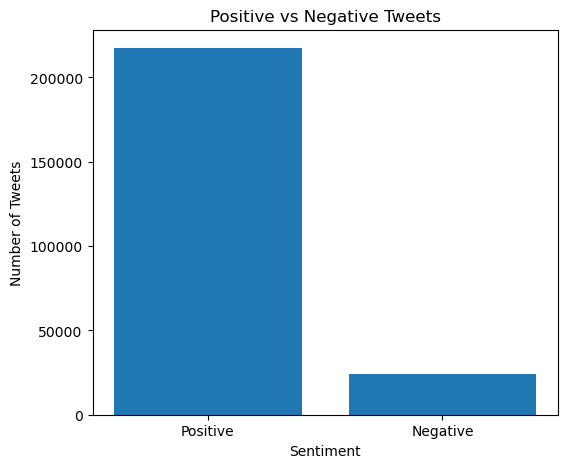

In [28]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Plot graph
plt.figure(figsize=(6,5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.title('Positive vs Negative Tweets')

plt.show()

In [30]:
percentage = (df['Sentiment'].value_counts(normalize=True)) * 100

print(percentage)

Sentiment
Positive    90.064461
Negative     9.935539
Name: proportion, dtype: float64
